# Decision Trees

## Diabetics Classification using Decision Tree

Our dataset contains information about family conditions and personal health data. Based on this health information, we are building a classification model to predict whether a person is at risk of developing diabetics.

In [1]:
import pandas as pd

In [2]:
diabetics = pd.read_csv('Files/diabetes_dataset.csv')
diabetics.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
diabetics.shape

(100000, 31)

In [4]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

dropping unncessary columns

In [5]:
diabetics.drop(['diabetes_risk_score','diabetes_stage'],axis=1,inplace = True)

sklearn Deccision tree model always takes input as numbers so converting the categorical columns into numericals

### Data Preprocessing

In [6]:
cat_cols = diabetics.select_dtypes(include=['object','category']).columns.tolist()

dummy_cols = pd.get_dummies(diabetics[cat_cols],drop_first=True).astype(int)

final_diabetes = pd.concat([diabetics,dummy_cols],axis=1)
final_diabetes.drop(cat_cols,axis=1,inplace=True)
final_diabetes.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,education_level_Postgraduate,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Former,smoking_status_Never
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,0,0,1,0,0,0,0,0,0,1
1,48,1,143,6.7,6.5,8.7,0,0,0,23.1,...,0,0,0,1,0,0,0,0,1,0
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,0,0,0,1,0,0,0,1,0,1
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,0,1,0,0,0,1,0,0,0,1
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,0,0,0,1,0,1,0,0,0,1


### Data splitting

In [7]:
X = final_diabetes.drop('diagnosed_diabetes',axis=1)
y = final_diabetes['diagnosed_diabetes']

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y, train_size=0.7,random_state=87)

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((70000, 40), (30000, 40), (70000,), (30000,))

Fitting the decision tree with default hyperparameters, intialize max_depth to 5 so that we can visualize

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_class = DecisionTreeClassifier(max_depth = 5)

dt_class.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
# Plotting Graph
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus


def get_classification_tree_graph(dt_model):
    dot_data = StringIO()
    export_graphviz(dt_model,out_file=dot_data,filled=True,rounded=True,
                    feature_names=X.columns,
                    class_names=['Diabetics','No Diabetics'])
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph


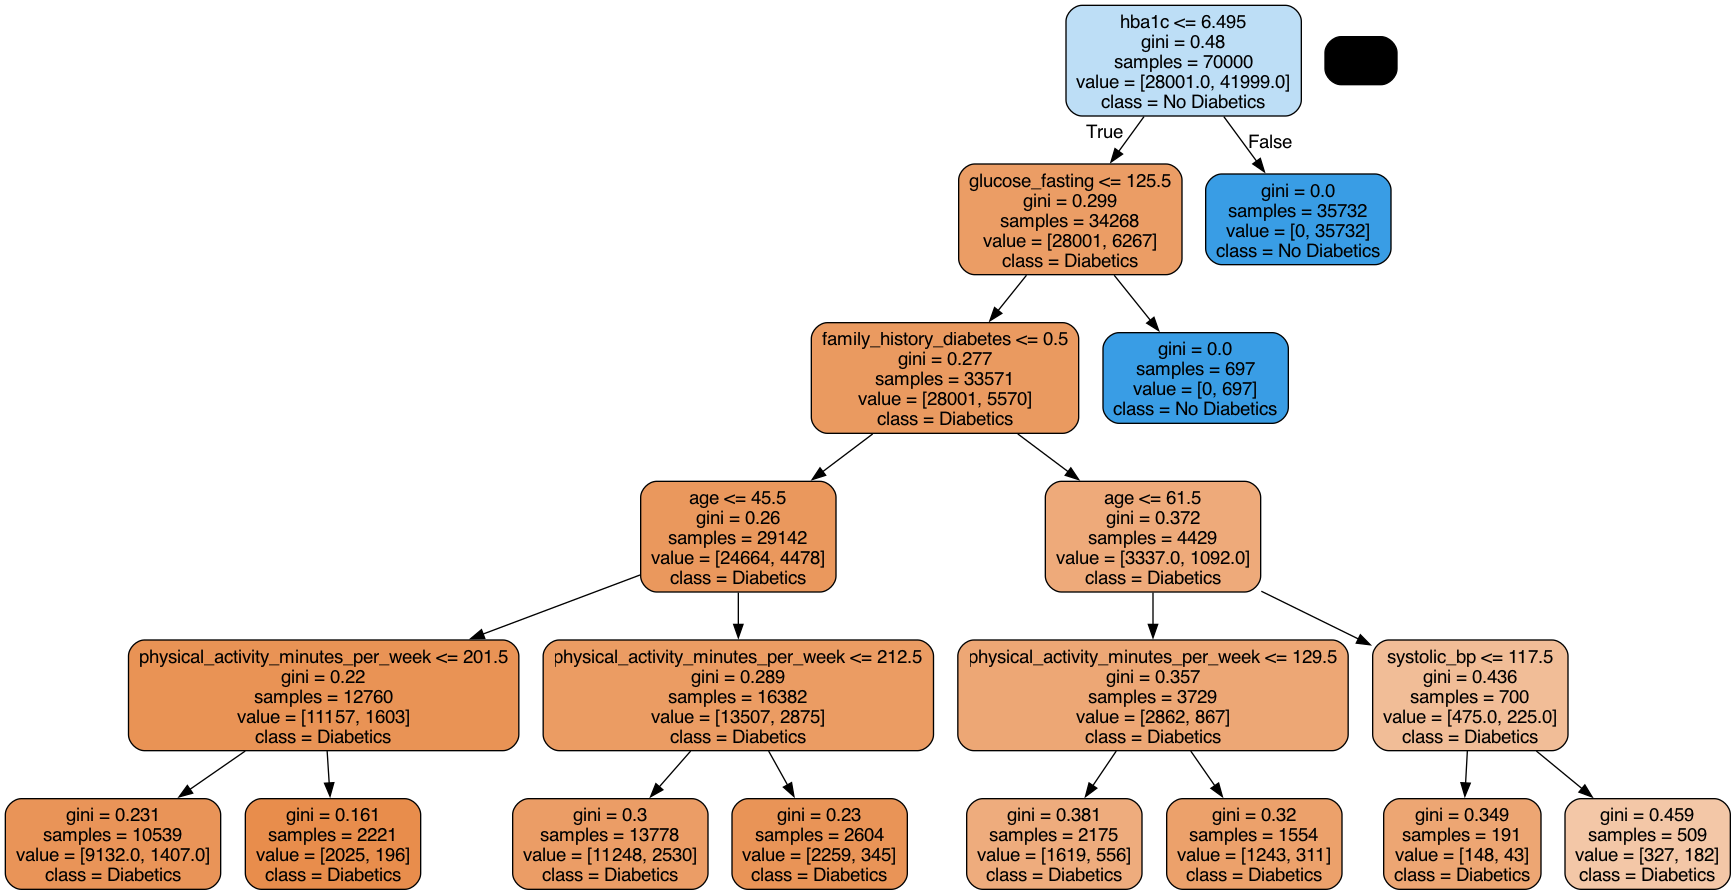

In [11]:
graph = get_classification_tree_graph(dt_class)
Image(graph.create_png())

In [12]:
from sklearn.metrics import classification_report


In [13]:
print(classification_report(y_train, dt_class.predict(X_train)))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91     28001
           1       1.00      0.87      0.93     41999

    accuracy                           0.92     70000
   macro avg       0.92      0.93      0.92     70000
weighted avg       0.93      0.92      0.92     70000



In [14]:

print(classification_report(y_test, dt_class.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91     12001
           1       1.00      0.87      0.93     17999

    accuracy                           0.92     30000
   macro avg       0.92      0.94      0.92     30000
weighted avg       0.94      0.92      0.92     30000



### Hyper Parameter Tunning

In [15]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [3,4,5,6,7],
    'min_samples_leaf':[5,10,15,20,30],
    'min_samples_split' :[10,20,25,30],

    'criterion':['gini','entropy']
}

In [16]:
dt_new_class = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator = dt_new_class,
                           param_grid = params,
                           cv=4,
                           n_jobs=-1)

In [17]:
grid_search.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [10, 20, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [18]:
score_df = pd.DataFrame(grid_search.cv_results_)
score_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.162865,0.007895,0.010091,0.001714,gini,3,5,10,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.919657,0.9208,0.9216,0.919657,0.920429,0.000822,1
1,0.157044,0.016423,0.010192,0.001850,gini,3,5,20,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.919657,0.9208,0.9216,0.919657,0.920429,0.000822,1
2,0.168015,0.003581,0.012141,0.005220,gini,3,5,25,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.919657,0.9208,0.9216,0.919657,0.920429,0.000822,1
3,0.152644,0.005162,0.007829,0.002758,gini,3,5,30,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.919657,0.9208,0.9216,0.919657,0.920429,0.000822,1
4,0.154600,0.005122,0.008075,0.001170,gini,3,10,10,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.919657,0.9208,0.9216,0.919657,0.920429,0.000822,1


In [19]:
grid_search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
dt_best = grid_search.best_estimator_

In [21]:
print(classification_report(y_train, dt_best.predict(X_train)))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91     28001
           1       1.00      0.87      0.93     41999

    accuracy                           0.92     70000
   macro avg       0.92      0.93      0.92     70000
weighted avg       0.93      0.92      0.92     70000



In [22]:
print(classification_report(y_test, dt_class.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91     12001
           1       1.00      0.87      0.93     17999

    accuracy                           0.92     30000
   macro avg       0.92      0.94      0.92     30000
weighted avg       0.94      0.92      0.92     30000



##  USA Real Estate Sales 2001-2023 Using Decision Tree


In [23]:
raw_sales = pd.read_excel('Files/usa_real_estate_2019_2021.xlsx')
raw_sales.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,179990,362500.0,0.4965,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988)
1,211386,2021,04/18/2022,Bridgeport,55 CANNON ST,110610,50000.0,2.2122,Vacant Land,NaN,NaN,NaN,NaN,POINT (-73.19020596 41.178257983)
2,212036,2021,2022-08-08 00:00:00,Bridgeport,540 JAMES ST,252150,650000.0,0.3879,Commercial,NaN,NaN,NaN,NaN,POINT (-73.204413035 41.183766989)
3,212150,2021,08/30/2022,Bridgeport,126 KENNEDY DR,70850,130000.0,0.5450,Residential,Condo,NaN,NaN,NaN,POINT (-73.221583028 41.214441988)
4,211190,2021,2022-08-08 00:00:00,Bristol,477 PERKINS ST,45010,99900.0,0.4505,Vacant Land,NaN,NaN,NaN,NaN,POINT (-72.966378188 41.695721379)


In [24]:
## Removing year and serial number
sales = raw_sales.drop(['Serial Number','List Year'],axis=1)

In [25]:
round(sales.isnull().sum() / sales.shape[0] *100,2 )

Date Recorded        0.00
Town                 0.00
Address              0.00
Assessed Value       0.00
Sale Amount          0.00
Sales Ratio          0.00
Property Type       36.44
Residential Type    37.53
Non Use Code        71.33
Assessor Remarks    84.71
OPM remarks         98.92
Location            75.79
dtype: float64

In [26]:
''' Removing  Non Use Code ,  Assessor Remarks, OPM remarks , Location
because these columns are having too many null values
'''

sales.drop(['Non Use Code' ,  'Assessor Remarks', 'OPM remarks' , 'Location'],inplace=True,axis=1)

In [27]:
''' In this case, vacant land and commercial properties do not have any associated residential type, whereas residential types are 
important for our analysis. Therefore, for such records, we will replace the missing values in the Residential Type column with "Other" instead of leaving them as NaN.

Additionally, we will remove rows where the Property Type is null, since this column is more critical for our model.
'''
sales = sales[sales['Property Type'].notnull()]

sales.loc[sales["Property Type"].isin(["Vacant Land", "Commercial"]), "Residential Type"] = "Other"

In [28]:
round(sales.isnull().sum() / sales.shape[0] *100,2)

Date Recorded       0.00
Town                0.00
Address             0.00
Assessed Value      0.00
Sale Amount         0.00
Sales Ratio         0.00
Property Type       0.00
Residential Type    0.22
dtype: float64

In [29]:
sales = sales[~(sales['Residential Type'].isnull())]
round(sales.isnull().sum() / sales.shape[0] *100,2)

Date Recorded       0.0
Town                0.0
Address             0.0
Assessed Value      0.0
Sale Amount         0.0
Sales Ratio         0.0
Property Type       0.0
Residential Type    0.0
dtype: float64

In [30]:
sales.describe()

,Assessed Value,Sale Amount,Sales Ratio
count,6.650290e+05,6.650290e+05,6.650290e+05
mean,2.565432e+05,3.782255e+05,5.304078e+00
std,1.315931e+06,1.142537e+06,1.722915e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.096900e+05,1.530000e+05,5.655699e-01
50%,1.593200e+05,2.400000e+05,6.763448e-01
75%,2.482000e+05,3.800000e+05,8.256000e-01
max,8.815100e+08,3.187900e+08,1.226420e+06


In [31]:
sales["Sale Amount"].quantile([0.90,0.95,0.97,0.99])

0.90     650000.0
0.95     999000.0
0.97    1425000.0
0.99    2687500.0
Name: Sale Amount, dtype: float64

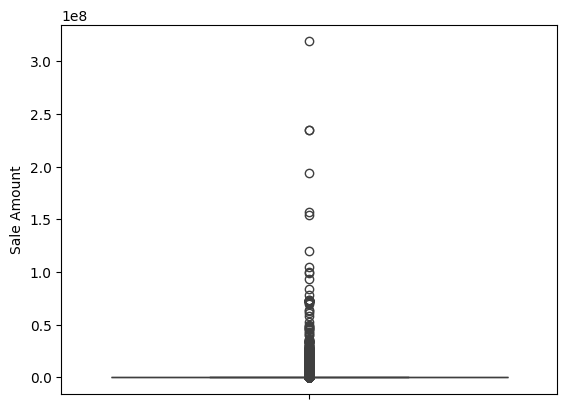

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.boxplot(sales["Sale Amount"])

plt.show()

In [33]:
''' There is an outlier in the data so we are removing the outliers from the data'''
final_sales = sales[sales["Sale Amount"]<1000000000]

In [34]:
final_sales.head()

,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,06/20/2022,Avon,12 BYRON DRIVE,179990,362500.0,0.4965,Residential,Condo
1,04/18/2022,Bridgeport,55 CANNON ST,110610,50000.0,2.2122,Vacant Land,Other
2,2022-08-08 00:00:00,Bridgeport,540 JAMES ST,252150,650000.0,0.3879,Commercial,Other
3,08/30/2022,Bridgeport,126 KENNEDY DR,70850,130000.0,0.5450,Residential,Condo
4,2022-08-08 00:00:00,Bristol,477 PERKINS ST,45010,99900.0,0.4505,Vacant Land,Other


In [35]:
final_sales["Sale Date"] = pd.to_datetime(final_sales["Date Recorded"])
final_sales["Sale_Year"] = final_sales["Sale Date"].dt.year
final_sales["Sale_Month"] = final_sales["Sale Date"].dt.month
final_sales["Sale_Day"] = final_sales["Sale Date"].dt.day
final_sales.drop('Date Recorded',axis=1,inplace=True)
final_sales.head()

,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Sale Date,Sale_Year,Sale_Month,Sale_Day
0,Avon,12 BYRON DRIVE,179990,362500.0,0.4965,Residential,Condo,2022-06-20,2022,6,20
1,Bridgeport,55 CANNON ST,110610,50000.0,2.2122,Vacant Land,Other,2022-04-18,2022,4,18
2,Bridgeport,540 JAMES ST,252150,650000.0,0.3879,Commercial,Other,2022-08-08,2022,8,8
3,Bridgeport,126 KENNEDY DR,70850,130000.0,0.5450,Residential,Condo,2022-08-30,2022,8,30
4,Bristol,477 PERKINS ST,45010,99900.0,0.4505,Vacant Land,Other,2022-08-08,2022,8,8


In [36]:
"""
Since there are too many unique addresses, it is not practical to convert them into numerical features for modeling. 
Instead of using the full address, we can aggregate the data at a higher level, such as town-wise sales. 
Additionally, the 'Sale Year' column can be removed, as it does not provide significant value for our model.
"""
final_sales.drop(['Sale_Year','Address','Sale Date','Sales Ratio'],axis = 1,inplace = True)
final_sales.head()

,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Sale_Month,Sale_Day
0,Avon,179990,362500.0,Residential,Condo,6,20
1,Bridgeport,110610,50000.0,Vacant Land,Other,4,18
2,Bridgeport,252150,650000.0,Commercial,Other,8,8
3,Bridgeport,70850,130000.0,Residential,Condo,8,30
4,Bristol,45010,99900.0,Vacant Land,Other,8,8


In [37]:
cat_cols = final_sales.select_dtypes(include=['object','category']).columns.tolist()

dummy_cols = pd.get_dummies(final_sales[cat_cols],drop_first=True).astype(int)

final_sales = pd.concat([final_sales,dummy_cols],axis=1)
final_sales.drop(cat_cols,axis=1,inplace=True)
final_sales.head()

,Assessed Value,Sale Amount,Sale_Month,Sale_Day,Town_Andover,Town_Ansonia,Town_Ashford,Town_Avon,Town_Barkhamsted,Town_Beacon Falls,...,Property Type_Residential,Property Type_Single Family,Property Type_Three Family,Property Type_Two Family,Property Type_Vacant Land,Residential Type_Four Family,Residential Type_Other,Residential Type_Single Family,Residential Type_Three Family,Residential Type_Two Family
0,179990,362500.0,6,20,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
1,110610,50000.0,4,18,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,252150,650000.0,8,8,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,70850,130000.0,8,30,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,45010,99900.0,8,8,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0


### Data splitting

In [38]:
X = final_sales.drop('Sale Amount',axis=1)
y = final_sales['Sale Amount']

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=87,train_size=0.7)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((465520, 184), (199509, 184), (465520,), (199509,))

In [44]:
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(max_depth = 3)

dt_reg.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [45]:
# Plotting Graph
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus


def get_regression_tree_graph(dt_model):
    dot_data = StringIO()
    export_graphviz(dt_model,out_file=dot_data,filled=True,rounded=True,
                    feature_names=X.columns)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph

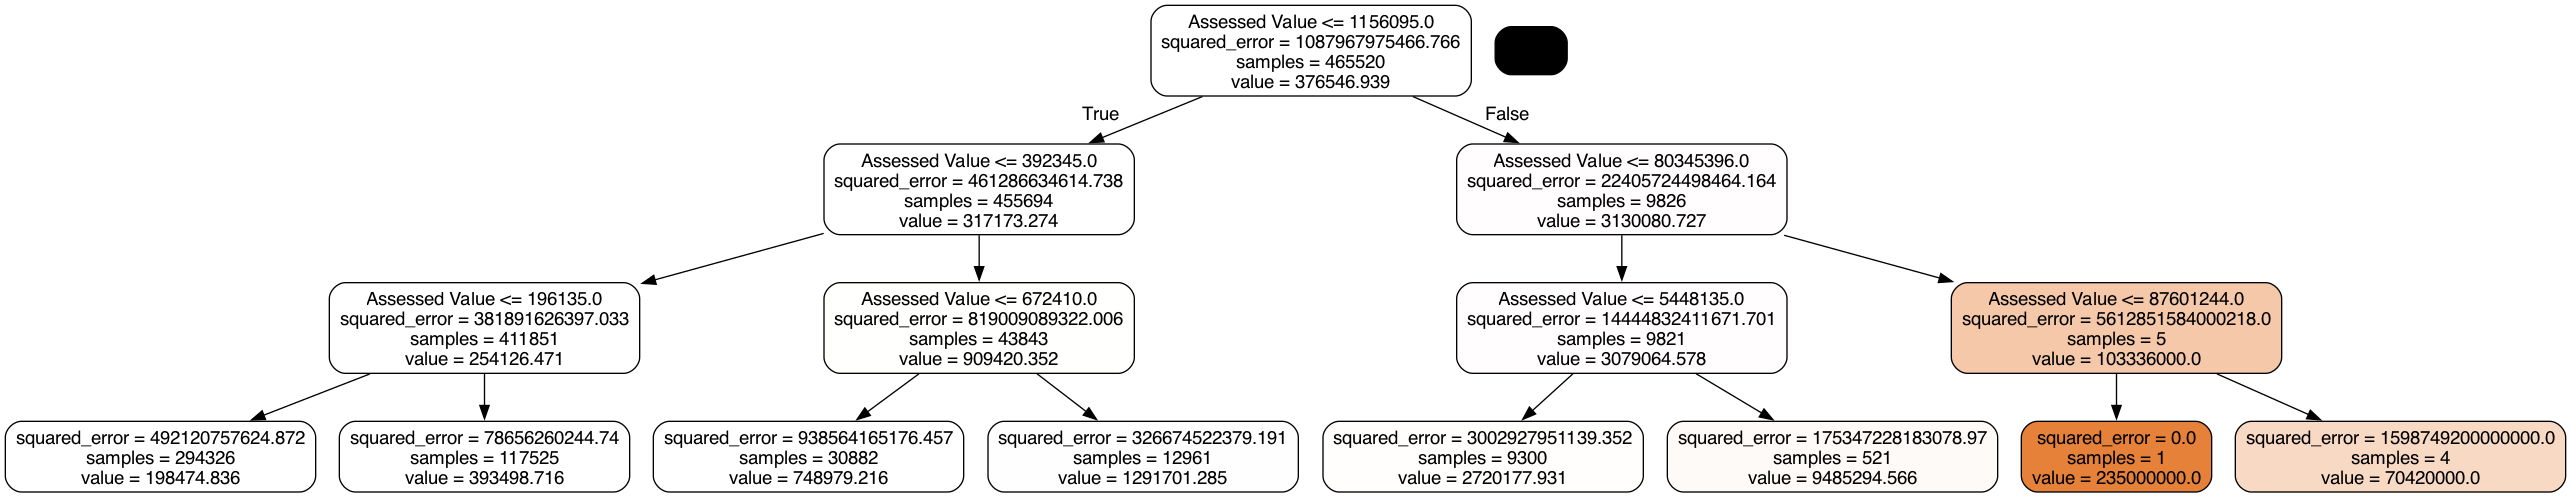

In [46]:
image = get_regression_tree_graph(dt_reg)
Image(image.create_png())

In [47]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
def regression_metrics(actual,predict):
    print("r2 Score ",round(r2_score(actual,predict),2))
    print("Mean Squared Error ",round(mean_squared_error(actual,predict),2))
    print("Mean Absolute Error ",round(mean_absolute_error(actual,predict),2))

In [48]:
regression_metrics(y_train,dt_reg.predict(X_train))

r2 Score  0.38
Mean Squared Error  672333972238.71
Mean Absolute Error  138327.58


In [49]:
regression_metrics(y_test,dt_reg.predict(X_test))

r2 Score  0.18
Mean Squared Error  1489158315559.87
Mean Absolute Error  144795.28


### Hyper Parameter tuning

In [50]:
params = {
    'max_depth' : [3,4,5,6,7],
    'min_samples_leaf':[5,10,15,20,30],
    'min_samples_split' :[10,20,25,30],
}

dt_new_reg = DecisionTreeRegressor()
grid_search = GridSearchCV(estimator = dt_new_reg,
                           param_grid = params,
                           cv=4,
                           n_jobs=-1)
grid_search.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [10, 20, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [51]:
dt_reg_best = grid_search.best_estimator_
dt_reg_best

,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,30
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [52]:
regression_metrics(y_train,dt_reg_best.predict(X_train))

r2 Score  0.5
Mean Squared Error  542061551389.35
Mean Absolute Error  107431.19


In [53]:
regression_metrics(y_test,dt_reg_best.predict(X_test))

r2 Score  0.35
Mean Squared Error  1171890254686.28
Mean Absolute Error  112896.95
